# Assignment 2
**Passing Marks:** 65 points

---
## Objective
The objective of this assignment is to understand and apply image processing techniques on a
dataset.

You have image datasets on blackboard. You are also allowed to use any other dataset from outside
sources (with the basic description).

For each task in this assignment:

1. Clarity of Explanation: 30%
2. Quality of Results: 30%
3. Insight in Discussion: 40%


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Fourier Transform (20 points)

1. Load a grayscale image and apply the 2D Discrete Fourier Transform (DFT) to it. Visualize
the original image and its frequency spectrum (magnitude). Submit the images, and
explanation.

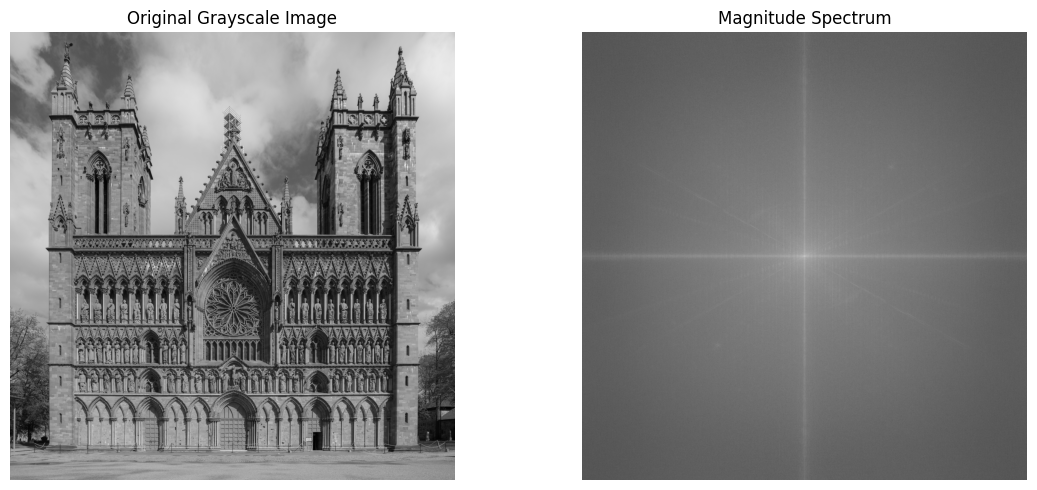

In [3]:
# --- Step 1: Load the image in grayscale ---
# Replace 'image.jpg' with your own image path
image = cv2.imread('images/lbp/nidaros.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not found or unable to load. Check the path!")

# --- Step 2: Apply 2D Discrete Fourier Transform (DFT) ---
# Compute the 2D FFT
dft = np.fft.fft2(image)

# Shift the zero-frequency component to the center
dft_shifted = np.fft.fftshift(dft)

# --- Step 3: Compute the magnitude spectrum ---
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)  # +1 to avoid log(0)

# --- Step 4: Display the results ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Original Grayscale Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Magnitude Spectrum')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

2. Implement a low-pass filter in the frequency domain to remove high-frequency noise from
an image. Compare the filtered image with the original image. Submit images, and analysis
of the results.

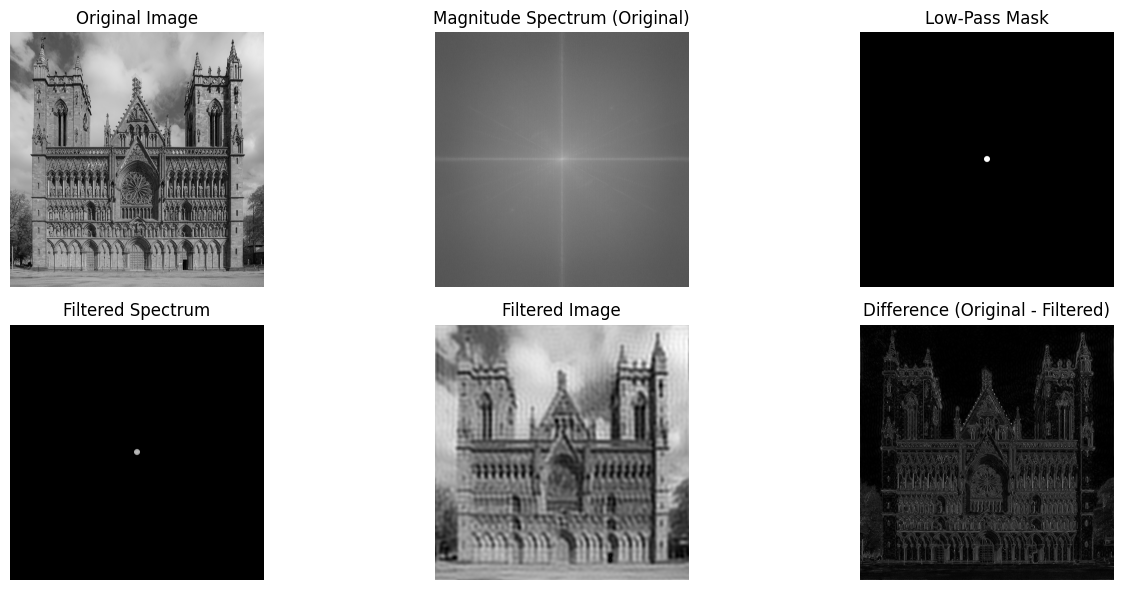

In [6]:
# --- Step 3: Create a Low-Pass Filter Mask ---
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2  # center

# Define filter radius (you can experiment with this)
radius = 50  

# Create a circular low-pass mask
mask = np.zeros((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), radius, 1, thickness=-1)

# --- Step 4: Apply mask (filter in frequency domain) ---
filtered_dft = dft_shifted * mask

# --- Step 5: Inverse FFT to get the filtered image ---
f_ishift = np.fft.ifftshift(filtered_dft)
filtered_image = np.fft.ifft2(f_ishift)
filtered_image = np.abs(filtered_image)

# --- Step 6: Compute magnitude spectrum (for visualization) ---
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)
filtered_spectrum = 20 * np.log(np.abs(filtered_dft) + 1)

# --- Step 7: Display results ---
plt.figure(figsize=(14, 6))

plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Magnitude Spectrum (Original)')
plt.imshow(magnitude_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Low-Pass Mask')
plt.imshow(mask * 255, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title('Filtered Spectrum')
plt.imshow(filtered_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title('Filtered Image')
plt.imshow(filtered_image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title('Difference (Original - Filtered)')
plt.imshow(cv2.absdiff(image, filtered_image.astype(np.uint8)), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

3. Implement a high-pass filter to enhance the edges in an image. Visualize the filtered image
and discuss the effects observed. Submit images, and explanation.

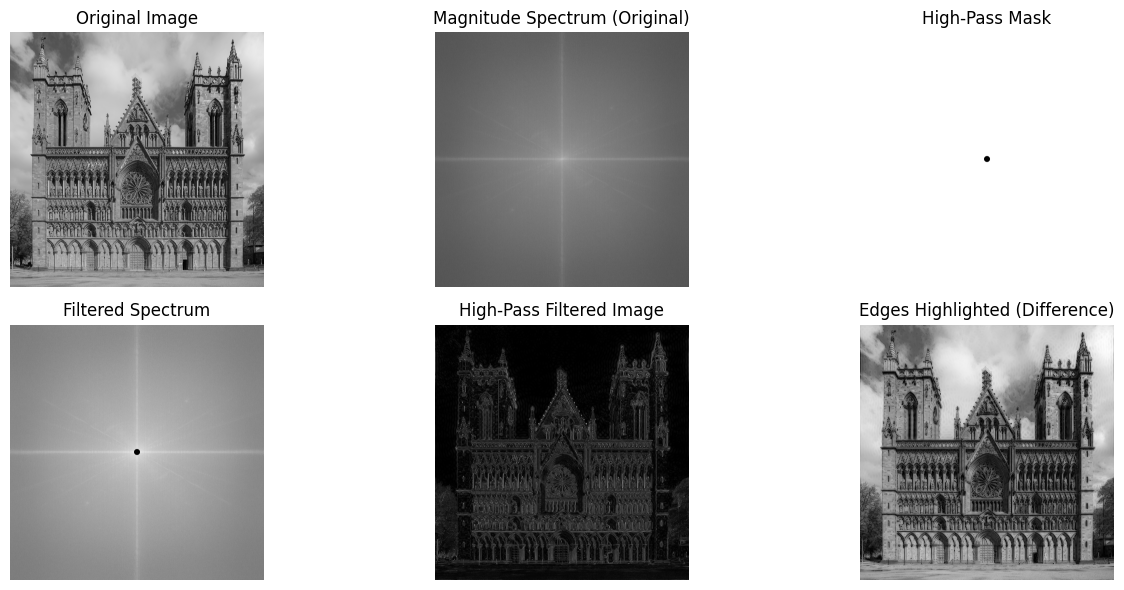

In [8]:
# --- Step 3: Create a High-Pass Filter Mask ---
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2  # center
radius = 50  # radius of low-frequency region to suppress

# Start with all ones, then zero out the center (low frequencies)
mask = np.ones((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), radius, 0, thickness=-1)

# --- Step 4: Apply mask (filter in frequency domain) ---
filtered_dft = dft_shifted * mask

# --- Step 5: Inverse FFT to reconstruct the image ---
f_ishift = np.fft.ifftshift(filtered_dft)
filtered_image = np.fft.ifft2(f_ishift)
filtered_image = np.abs(filtered_image)

# --- Step 6: Compute magnitude spectra for visualization ---
original_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)
filtered_spectrum = 20 * np.log(np.abs(filtered_dft) + 1)

# --- Step 7: Display results ---
plt.figure(figsize=(14, 6))

plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Magnitude Spectrum (Original)')
plt.imshow(original_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('High-Pass Mask')
plt.imshow(mask * 255, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title('Filtered Spectrum')
plt.imshow(filtered_spectrum, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title('High-Pass Filtered Image')
plt.imshow(filtered_image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title('Edges Highlighted (Difference)')
diff = cv2.absdiff(image, np.uint8(np.clip(filtered_image, 0, 255)))
plt.imshow(diff, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

4. Implement an image compression technique using Fourier Transform by selectively keeping
only a certain percentage of the Fourier coefficients. Evaluate the quality of the
reconstructed image as you vary the percentage of coefficients used. Submit the images,
and your observations on image quality and compression ratio.


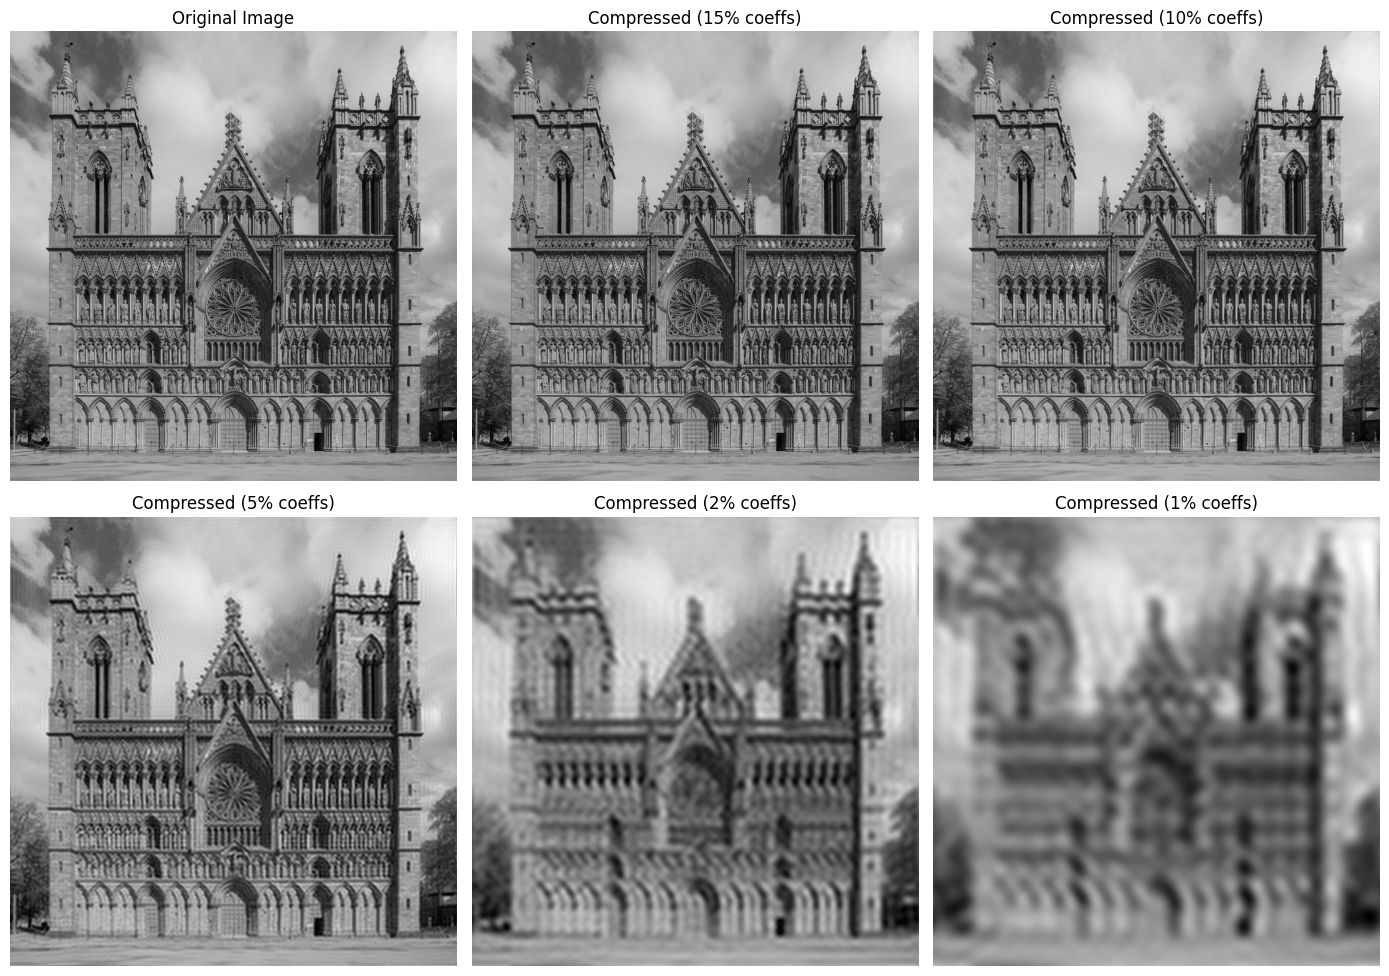

In [11]:
# --- Step 3: Selectively keep only top percentage of coefficients ---
def compress_fourier(dft_shifted, keep_fraction):
    """Keep only a given fraction of the top Fourier coefficients."""
    rows, cols = dft_shifted.shape
    crow, ccol = rows // 2, cols // 2

    # Define the size of the region to keep
    r_keep = int(crow * keep_fraction)
    c_keep = int(ccol * keep_fraction)

    mask = np.zeros((rows, cols), np.uint8)
    mask[crow - r_keep:crow + r_keep, ccol - c_keep:ccol + c_keep] = 1

    # Apply mask to keep only low-frequency components
    compressed_dft = dft_shifted * mask
    return compressed_dft, mask

# Keep different percentages of Fourier coefficients for comparison
fractions = [0.15, 0.1, 0.05, 0.02, 0.01]
reconstructed_images = []

for f in fractions:
    compressed_dft, mask = compress_fourier(dft_shifted, f)
    
    # --- Step 4: Inverse FFT to reconstruct image ---
    f_ishift = np.fft.ifftshift(compressed_dft)
    reconstructed = np.fft.ifft2(f_ishift)
    reconstructed = np.abs(reconstructed)
    reconstructed_images.append((f, reconstructed, mask))

# --- Step 5: Display results ---
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

for i, (frac, recon, mask) in enumerate(reconstructed_images):
    plt.subplot(2, 3, i + 2)
    plt.title(f"Compressed ({int(frac*100)}% coeffs)")
    plt.imshow(recon, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()



## PCA (25 points)
Select a set of grayscale images (e.g., faces, landscapes, or any other category).

Normalize the images by scaling pixel values to a range [0, 1].

### PCA Implementation:
Write a Python function to perform PCA on the images.
Implement the following steps:

1. Convert the image into a 2D matrix where each row represents an image and each column
represents a pixel value.
2. Compute the covariance matrix of the image data.
3. Calculate the eigenvalues and eigenvectors of the covariance matrix.
4. Sort the eigenvectors based on the eigenvalues in descending order.
5. Select the top k eigenvectors to form the principal components.
6. Project the original images onto the lower-dimensional subspace defined by the selected
principal components

In [ ]:
# Your code for PCA implementation


### Reconstruction of Images:

1. Using the selected principal components, reconstruct the images.
2. Compare the reconstructed images with the original images to observe the effects of
dimensionality reduction.

In [ ]:
# Your code for image reconstruction


### Experimentation:
1. Vary the number of principal components (k) and observe the impact on the quality of the
reconstructed images.
2. Plot the variance explained by the principal components and determine the optimal number
of components that balances compression and quality.

In [ ]:
# Your code for experimentation (variance plot, reconstruction comparison)


### Visual Analysis:
1. Display the original images alongside the reconstructed images for different values of k.
2. Comment on the visual quality of the images and how much information is lost during
compression.


In [ ]:
# Your code for visual analysis


### Error Analysis:
1. Compute the Mean Squared Error (MSE) between the original and reconstructed images.
2. Analyze the trade-off between compression and reconstruction error.

In [ ]:
# Your code for MSE calculation and analysis


## Image Processing (55 points)

### HOG Features (12 points)
1. Write a Python script to compute the HOG features of a given image using a library such as
OpenCV or scikit-image.
2. Apply your implementation to at least three different images, including both simple and
complex scenes.
3. Visualize the original image, the gradient image, and the HOG feature image.
4. Compare the HOG features extracted from different images. Discuss the impact of varying
parameters like cell size, block size, and the number of bins on the resulting HOG
descriptors.

In [ ]:
# Your code for HOG features computation and visualization


### Local Binary Patterns (LBP) (13 points)
1. Write a Python function to compute the LBP of a given grayscale image. Use the basic 8-
neighbor LBP method.
2. Your function should output the LBP image, where each pixel is replaced by its
corresponding LBP value.
3. Write a Python function to compute the histogram of the LBP image.
4. Plot the histogram and explain what it represents in terms of the texture features of the
image.
5. Apply your LBP function to at least three different grayscale images (e.g., a natural scene, a
texture, and a face image).
6. Generate and compare the histograms of the LBP images.
7. Discuss the differences in the histograms and what they tell you about the textures of the
different images.

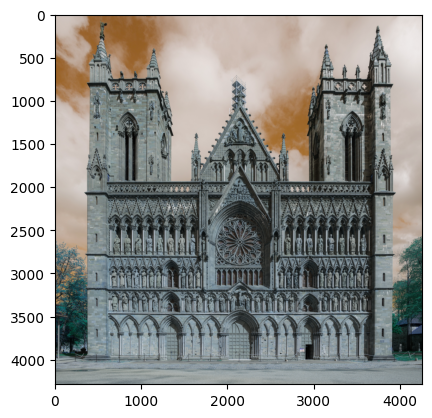

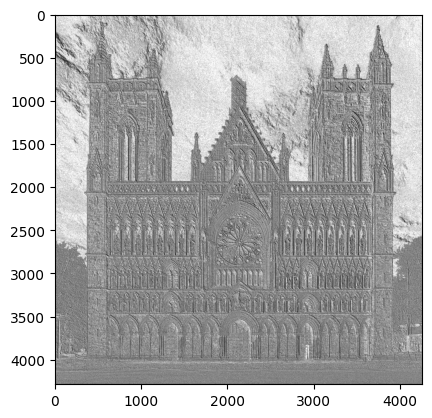

In [9]:
# Your code for LBP computation and histogram analysis

# local Binary Patterns
def get_pixel(img, center, x, y):
      
    new_value = 0
      
    try:
        # If local neighbourhood pixel 
        # value is greater than or equal
        # to center pixel values then 
        # set it to 1
        if img[x][y] >= center:
            new_value = 1
              
    except:
        # Exception is required when 
        # neighbourhood value of a center
        # pixel value is null i.e. values
        # present at boundaries.
        pass
      
    return new_value
   
# Function for calculating LBP
def lbp_calculated_pixel(img, x, y):
   
    center = img[x][y]
   
    val_ar = []
      
    # top_left
    val_ar.append(get_pixel(img, center, x-1, y-1))
      
    # top
    val_ar.append(get_pixel(img, center, x-1, y))
      
    # top_right
    val_ar.append(get_pixel(img, center, x-1, y + 1))
      
    # right
    val_ar.append(get_pixel(img, center, x, y + 1))
      
    # bottom_right
    val_ar.append(get_pixel(img, center, x + 1, y + 1))
      
    # bottom
    val_ar.append(get_pixel(img, center, x + 1, y))
      
    # bottom_left
    val_ar.append(get_pixel(img, center, x + 1, y-1))
      
    # left
    val_ar.append(get_pixel(img, center, x, y-1))
       
    # Now, we need to convert binary
    # values to decimal
    power_val = [1, 2, 4, 8, 16, 32, 64, 128]
   
    val = 0
      
    for i in range(len(val_ar)):
        val += val_ar[i] * power_val[i]
          
    return val
   
path = 'images/lbp/nidaros.jpg'
img_bgr = cv2.imread(path, 1)
   
height, width, _ = img_bgr.shape
   
# We need to convert RGB image 
# into gray one because gray 
# image has one channel only.
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
   
# Create a numpy array as 
# the same height and width 
# of RGB image
img_lbp = np.zeros((height, width), np.uint8)
   
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
  
plt.imshow(img_bgr)
plt.show()
   
plt.imshow(img_lbp, cmap ="gray")
plt.show()
   


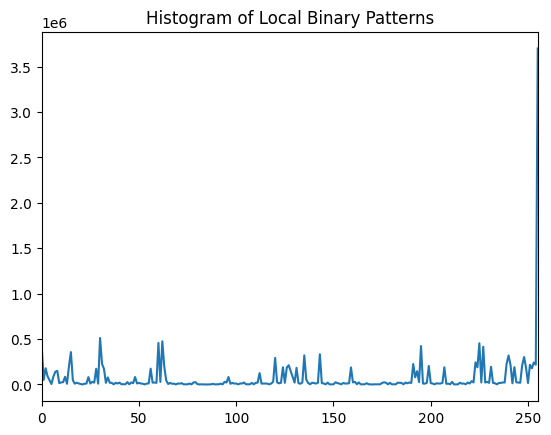

In [10]:
#once we have the local binary patterns, now create the histogram
hist,bin = np.histogram(img_lbp.ravel(),256,[0,255])
plt.xlim([0,255])
plt.plot(hist)
plt.title('Histogram of Local Binary Patterns')
plt.show()


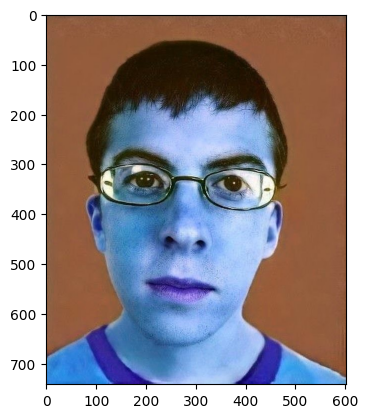

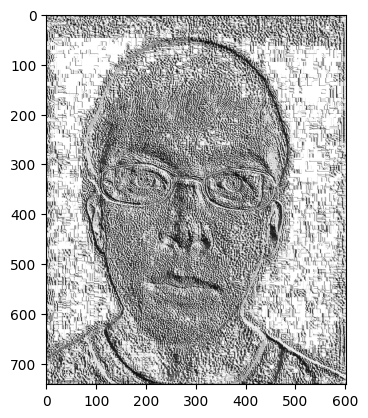

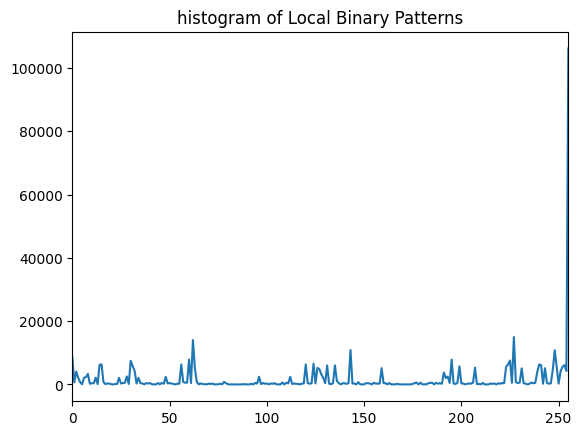

In [12]:
path = 'images/lbp/mclovin.jpg'
img_bgr = cv2.imread(path, 1)
   
height, width, _ = img_bgr.shape
   
# We need to convert RGB image 
# into gray one because gray 
# image has one channel only.
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
   
# Create a numpy array as 
# the same height and width 
# of RGB image
img_lbp = np.zeros((height, width), np.uint8)
   
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
  
plt.imshow(img_bgr)
plt.show()
   
plt.imshow(img_lbp, cmap ="gray")
plt.show()

#once we have the local binary patterns, now create the histogram
hist,bin = np.histogram(img_lbp.ravel(),256,[0,255])
plt.xlim([0,255])
plt.plot(hist)
plt.title('histogram of Local Binary Patterns')
plt.show()

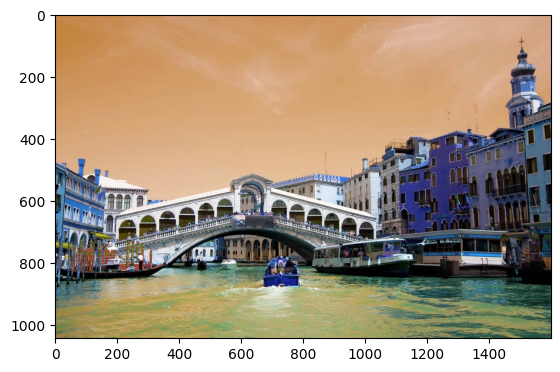

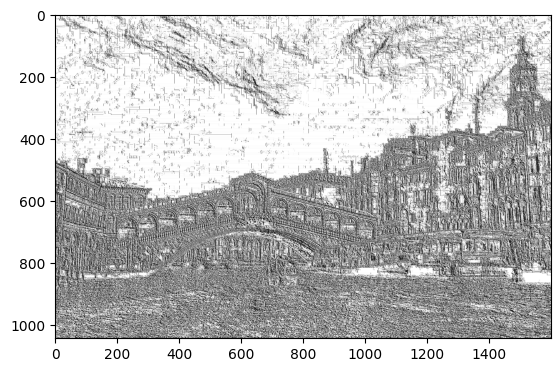

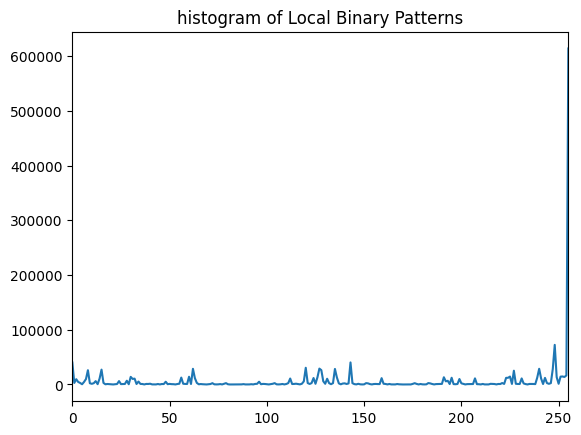

In [15]:
path = 'images/lbp/venice.jpg'
img_bgr = cv2.imread(path, 1)
   
height, width, _ = img_bgr.shape
   
# We need to convert RGB image 
# into gray one because gray 
# image has one channel only.
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
   
# Create a numpy array as 
# the same height and width 
# of RGB image
img_lbp = np.zeros((height, width), np.uint8)
   
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
  
plt.imshow(img_bgr)
plt.show()
   
plt.imshow(img_lbp, cmap ="gray")
plt.show()

#once we have the local binary patterns, now create the histogram
hist,bin = np.histogram(img_lbp.ravel(),256,[0,255])
plt.xlim([0,255])
plt.plot(hist)
plt.title('histogram of Local Binary Patterns')
plt.show()

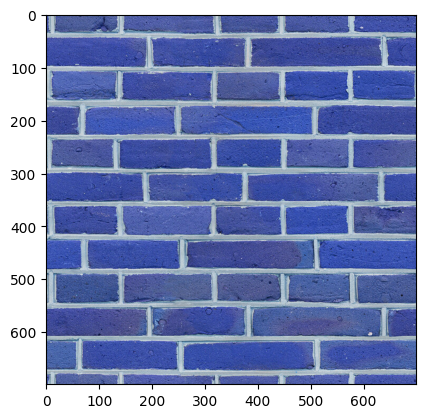

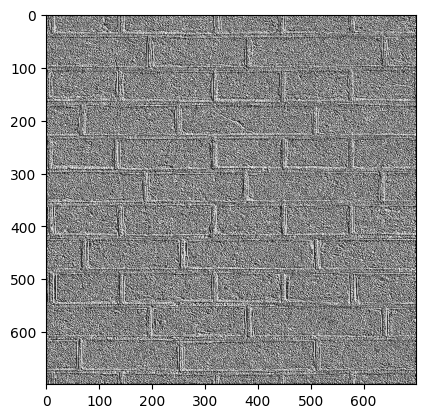

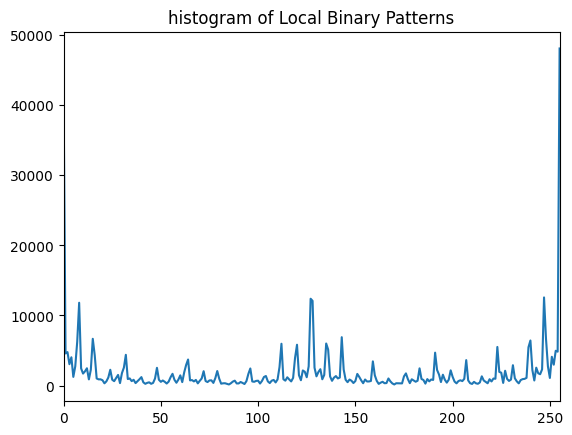

In [21]:
path = 'images/lbp/wall.jpg'
img_bgr = cv2.imread(path, 1)
   
height, width, _ = img_bgr.shape
   
# We need to convert RGB image 
# into gray one because gray 
# image has one channel only.
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
   
# Create a numpy array as 
# the same height and width 
# of RGB image
img_lbp = np.zeros((height, width), np.uint8)
   
for i in range(0, height):
    for j in range(0, width):
        img_lbp[i, j] = lbp_calculated_pixel(img_gray, i, j)
  
plt.imshow(img_bgr)
plt.show()
   
plt.imshow(img_lbp, cmap ="gray")
plt.show()

#once we have the local binary patterns, now create the histogram
hist,bin = np.histogram(img_lbp.ravel(),256,[0,255])
plt.xlim([0,255])
plt.plot(hist)
plt.title('histogram of Local Binary Patterns')
plt.show()

In [22]:
print(hist)

[41151  4589  4777  3054  4044  1246  2756  6248 11818  2460  1718  2039
  2475   888  2276  6677  4353  1019   893   897   770   328   611  1156
  2261   840   635  1066  1524   356  1786  2572  4392   938  1026   643
   830   357   630   907  1213   471   259   394   471   260   383  1012
  2541   837   540   732   545   300   568  1192  1683   829   411   849
  1464   500  1882  2950  3724   745   795   598   815   321   684  1018
  2057   655   507   742   751   384  1062  2080   995   278   331   339
   258   163   338   572   707   311   312   517   384   228   642  1674
  2446   593   547   674   700   299   667  1227  1371   608   363   706
   810   455   878  2640  5970   909   708  1184   876   595  1102  3972
  5829  1482   770  2161  1975  1196  2748 12389 12088  2556  1323  1940
  2342   905  1524  6008  5150  1319   686  1137  1360  1022  1151  6906
  2288   834   489   866   697   369   653  1668  1243   756   343   869
   592   594   664  3458  1468   677   248   422   

### Implement a blob detection algorithm (15 points).
1. Apply the blob detection algorithm to one of the provided image datasets on blackborad.
2. Visualize the detected blobs on the original images, marking each detected blob with a
circle or bounding box.
3. Calculate and display relevant statistics for each image, such as the number of blobs
detected, their sizes, and positions.
4. Evaluate and discuss the effect of different parameters in the algorithms on the detection of
different blobs.

In [ ]:
# Your code for blob detection


### Implement a contour detection algorithm. (15 points)
1. Apply the contour detection algorithm to the same image dataset.
2. Visualize the detected contours on the original images, marking each contour with a
different color.
3. Calculate and display relevant statistics for each image, such as the number of contours
detected, contour area, and perimeter.
4. Compare the results of blob detection and contour detection for the chosen dataset.
5. Discuss the advantages and limitations of each technique.
6. Analyze the impact of different parameters (e.g., threshold values, filter sizes) on the
detection results.
7. Provide examples where one technique might be more suitable than the other.

In [ ]:
# Your code for contour detection
